## **CNN Testing.**

In [1]:
# =========================================================
# IMPORTS
# =========================================================
import os
import random
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from tqdm import tqdm
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
# =========================================================
# TRAIN DATASET
# =========================================================
real_folder = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data_Final"
DP_GAN_spoofed = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/DP_GAN_SPOOFED_Final"
FA_GAN_spoofed = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/FA_GAN_SPOOFED_Final"


# =========================================================
# TEST DATASET
# =========================================================
test_real_folder = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/test/real_data"
BC_DCT = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/test/fake_data"

In [4]:
# =========================================================
# DATASET CLASS
# =========================================================
class SpoofDataset(Dataset):
    def __init__(self, image_label_list, transform=None):
        self.image_label_list = image_label_list
        self.transform = transform

    def __len__(self):
        return len(self.image_label_list)

    def __getitem__(self, idx):
        img_path, label = self.image_label_list[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# =========================================================
# LOAD IMAGE PATHS
# label 0 = real
# label 1 = fake
# =========================================================
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def load_images_from_folder(folder_path, label):
    image_list = []

    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith(valid_extensions):
            image_list.append((os.path.join(folder_path, file_name), label))

    return image_list

# =========================================================
# CONTROLLED SAMPLING FOR CNN EXPERIMENT
# =========================================================

random.seed(42)

def random_sample(image_list, sample_size, name):
    if len(image_list) < sample_size:
        raise ValueError(f"{name} has only {len(image_list)} images, requested {sample_size}")
    return random.sample(image_list, sample_size)


# load full data
real_train_full = load_images_from_folder(real_folder, 0)
dpgan_full = load_images_from_folder(DP_GAN_spoofed, 1)
fagan_full = load_images_from_folder(FA_GAN_spoofed, 1)

real_test_full = load_images_from_folder(test_real_folder, 0)
bcdct_full = load_images_from_folder(BC_DCT, 1)


# sample like POC
train_real_sample = random_sample(real_train_full, 8000, "Train Real")
train_dpgan_sample = random_sample(dpgan_full, 4000, "DP-GAN")
train_fagan_sample = random_sample(fagan_full, 4000, "FA-GAN")

test_real_sample = random_sample(real_test_full, 4000, "Test Real")
test_bcdct_sample = random_sample(bcdct_full, 4000, "BC-DCT")


train_data = train_real_sample + train_dpgan_sample + train_fagan_sample
test_data = test_real_sample + test_bcdct_sample

random.shuffle(train_data)
random.shuffle(test_data)

print("\n===== CONTROLLED DATA SUMMARY =====")
print("Train Real:", sum(1 for _, y in train_data if y == 0))
print("Train Fake:", sum(1 for _, y in train_data if y == 1))
print("Total Train:", len(train_data))

print("Test Real:", sum(1 for _, y in test_data if y == 0))
print("Test Fake:", sum(1 for _, y in test_data if y == 1))
print("Total Test:", len(test_data))



===== CONTROLLED DATA SUMMARY =====
Train Real: 8000
Train Fake: 8000
Total Train: 16000
Test Real: 4000
Test Fake: 4000
Total Test: 8000


In [5]:
# =========================================================
# CNN MODEL
# =========================================================
class StableBinaryCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 2)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

Saving all files to: /content/drive/MyDrive/Thesis_Final_Models
Using device: cuda

TRAINING CNN | IMAGE SIZE: 128x128 | SEED: 42


CNN 128px Epoch [1/15]: 100%|██████████| 250/250 [30:14<00:00,  7.26s/it, acc=57.20%, avg_loss=0.678, batch_loss=0.661]


Epoch [1/15] Average Loss: 0.6779 | Train Accuracy: 57.20%


CNN 128px Epoch [2/15]: 100%|██████████| 250/250 [00:48<00:00,  5.18it/s, acc=60.22%, avg_loss=0.661, batch_loss=0.69]


Epoch [2/15] Average Loss: 0.6609 | Train Accuracy: 60.22%


...

Epoch [14/15] Average Loss: 0.4862 | Train Accuracy: 77.65%


CNN 128px Epoch [15/15]: 100%|██████████| 250/250 [00:49<00:00,  5.04it/s, acc=78.49%, avg_loss=0.474, batch_loss=0.472]


Epoch [15/15] Average Loss: 0.4723 | Train Accuracy: 78.49%

Saved CNN model: /content/drive/MyDrive/Thesis_Final_Models/cnn_128_seed42.pth

----------------------------------------------------------------------
TESTING CNN | IMAGE SIZE: 128x128
----------------------------------------------------------------------


Testing CNN 128px: 100%|██████████| 125/125 [16:48<00:00,  8.07s/it]



========== FINAL CNN TEST RESULTS ==========
Image Size: 128x128
Seed: 42

True Positive  (Fake detected as Fake): 1301
True Negative  (Real detected as Real): 2481
False Positive (Real detected as Fake): 1519
False Negative (Fake detected as Real): 2699

Accuracy : 0.47275
Precision: 0.4613475177304965
Recall   : 0.32525
F1-score : 0.381524926686217

========== SPOOF DETECTION RESULT ==========
Total Fake Samples: 4000
Detected Fake Samples: 1301
Fake Detected as Real: 2699

Success Rate: 32.52%
Attack Pass Rate: 67.47%

Prediction Distribution:
Predicted Real: 5180
Predicted Fake: 2820


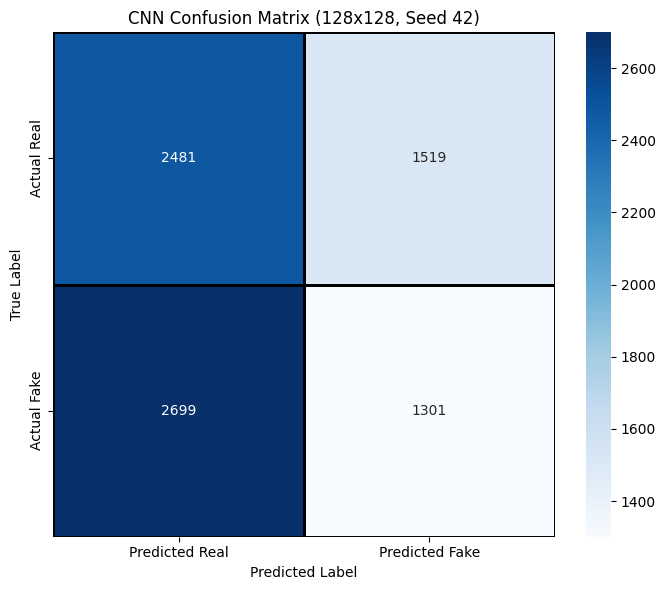

Saved confusion matrix: /content/drive/MyDrive/Thesis_Final_Models/cnn_cm_128_seed42.png

TRAINING CNN | IMAGE SIZE: 224x224 | SEED: 42


CNN 224px Epoch [1/15]: 100%|██████████| 250/250 [00:57<00:00,  4.35it/s, acc=60.96%, avg_loss=0.673, batch_loss=0.647]


Epoch [1/15] Average Loss: 0.6733 | Train Accuracy: 60.96%


CNN 224px Epoch [2/15]: 100%|██████████| 250/250 [00:58<00:00,  4.26it/s, acc=77.17%, avg_loss=0.553, batch_loss=0.459]


Epoch [2/15] Average Loss: 0.5531 | Train Accuracy: 77.17%


...

Epoch [14/15] Average Loss: 0.0752 | Train Accuracy: 97.78%


CNN 224px Epoch [15/15]: 100%|██████████| 250/250 [00:56<00:00,  4.40it/s, acc=97.91%, avg_loss=0.0679, batch_loss=0.0356]


Epoch [15/15] Average Loss: 0.0679 | Train Accuracy: 97.91%

Saved CNN model: /content/drive/MyDrive/Thesis_Final_Models/cnn_224_seed42.pth

----------------------------------------------------------------------
TESTING CNN | IMAGE SIZE: 224x224
----------------------------------------------------------------------


Testing CNN 224px: 100%|██████████| 125/125 [00:26<00:00,  4.77it/s]



========== FINAL CNN TEST RESULTS ==========
Image Size: 224x224
Seed: 42

True Positive  (Fake detected as Fake): 56
True Negative  (Real detected as Real): 3969
False Positive (Real detected as Fake): 31
False Negative (Fake detected as Real): 3944

Accuracy : 0.503125
Precision: 0.6436781609195402
Recall   : 0.014
F1-score : 0.027403963787619282

========== SPOOF DETECTION RESULT ==========
Total Fake Samples: 4000
Detected Fake Samples: 56
Fake Detected as Real: 3944

Success Rate: 1.40%
Attack Pass Rate: 98.60%

Prediction Distribution:
Predicted Real: 7913
Predicted Fake: 87


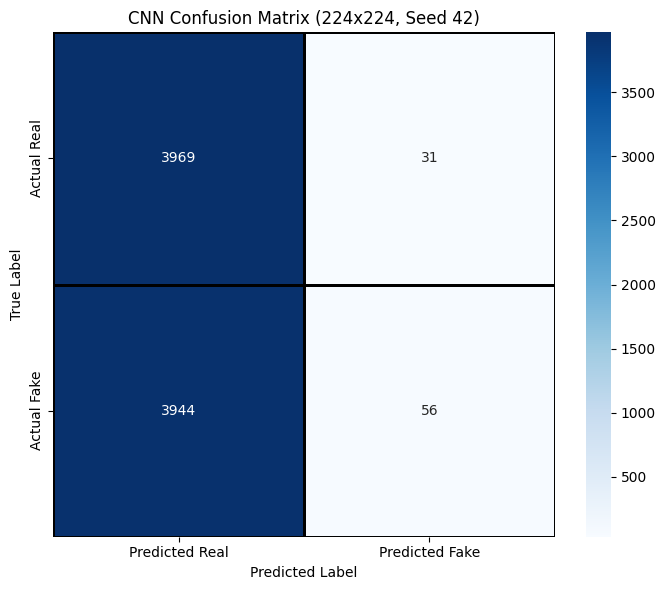

Saved confusion matrix: /content/drive/MyDrive/Thesis_Final_Models/cnn_cm_224_seed42.png

TRAINING CNN | IMAGE SIZE: 256x256 | SEED: 42


CNN 256px Epoch [1/15]: 100%|██████████| 250/250 [00:57<00:00,  4.31it/s, acc=77.94%, avg_loss=0.547, batch_loss=0.417]


Epoch [1/15] Average Loss: 0.5466 | Train Accuracy: 77.94%


CNN 256px Epoch [2/15]: 100%|██████████| 250/250 [00:58<00:00,  4.24it/s, acc=92.96%, avg_loss=0.279, batch_loss=0.167]


Epoch [2/15] Average Loss: 0.2789 | Train Accuracy: 92.96%


...

Epoch [14/15] Average Loss: 0.0165 | Train Accuracy: 99.62%


CNN 256px Epoch [15/15]: 100%|██████████| 250/250 [00:57<00:00,  4.33it/s, acc=99.65%, avg_loss=0.0148, batch_loss=0.0142]


Epoch [15/15] Average Loss: 0.0148 | Train Accuracy: 99.65%

Saved CNN model: /content/drive/MyDrive/Thesis_Final_Models/cnn_256_seed42.pth

----------------------------------------------------------------------
TESTING CNN | IMAGE SIZE: 256x256
----------------------------------------------------------------------


Testing CNN 256px: 100%|██████████| 125/125 [00:27<00:00,  4.62it/s]



========== FINAL CNN TEST RESULTS ==========
Image Size: 256x256
Seed: 42

True Positive  (Fake detected as Fake): 4
True Negative  (Real detected as Real): 3999
False Positive (Real detected as Fake): 1
False Negative (Fake detected as Real): 3996

Accuracy : 0.500375
Precision: 0.8
Recall   : 0.001
F1-score : 0.0019975031210986267

========== SPOOF DETECTION RESULT ==========
Total Fake Samples: 4000
Detected Fake Samples: 4
Fake Detected as Real: 3996

Success Rate: 0.10%
Attack Pass Rate: 99.90%

Prediction Distribution:
Predicted Real: 7995
Predicted Fake: 5


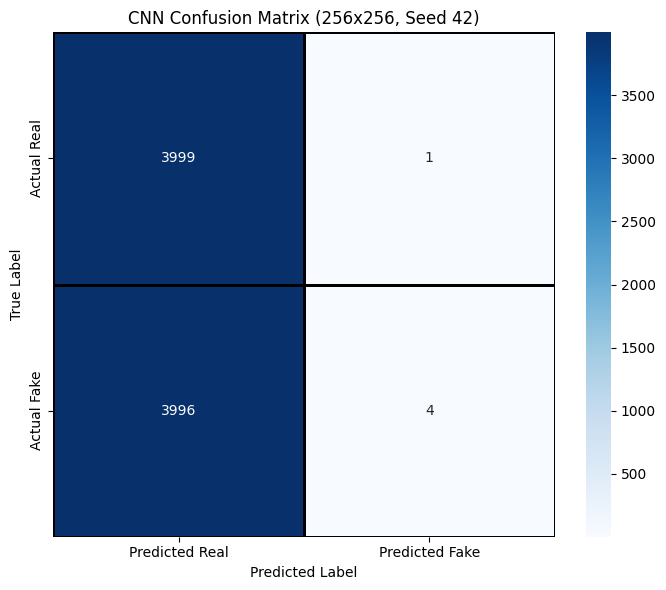

Saved confusion matrix: /content/drive/MyDrive/Thesis_Final_Models/cnn_cm_256_seed42.png


========== CNN SUMMARY: ALL IMAGE SIZES ==========

Image Size: 128
Seed: 42
TP: 1301 | TN: 2481 | FP: 1519 | FN: 2699
Accuracy: 0.47275
Precision: 0.4613475177304965
Recall: 0.32525
F1: 0.381524926686217
Success Rate: 32.52%
Attack Pass Rate: 67.47%

Image Size: 224
Seed: 42
TP: 56 | TN: 3969 | FP: 31 | FN: 3944
Accuracy: 0.503125
Precision: 0.6436781609195402
Recall: 0.014
F1: 0.027403963787619282
Success Rate: 1.40%
Attack Pass Rate: 98.60%

Image Size: 256
Seed: 42
TP: 4 | TN: 3999 | FP: 1 | FN: 3996
Accuracy: 0.500375
Precision: 0.8
Recall: 0.001
F1: 0.0019975031210986267
Success Rate: 0.10%
Attack Pass Rate: 99.90%


NameError: name 'pd' is not defined

In [8]:
import numpy as np
#=========================================================
# CNN TRAINING + TESTING WITH FIXED SEED + GOOGLE DRIVE SAVE
# =========================================================


# =========================================================
# GOOGLE DRIVE SAVE PATH
# =========================================================

SAVE_DIR = "/content/drive/MyDrive/Thesis_Final_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Saving all files to:", SAVE_DIR)

# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# FIXED SEED
# =========================================================
seed = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed)

# =========================================================
# TRAIN CNN FOR MULTIPLE IMAGE SIZES
# =========================================================
image_sizes = [128, 224, 256]

batch_size = 64
epochs = 15

all_results = []

for img_size in image_sizes:

    set_seed(seed)

    print("\n" + "=" * 70)
    print(f"TRAINING CNN | IMAGE SIZE: {img_size}x{img_size} | SEED: {seed}")
    print("=" * 70)

    # =====================================================
    # TRAIN TRANSFORM
    # =====================================================
    train_transform = transforms.Compose([

        transforms.Resize((img_size, img_size)),

        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomRotation(5),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # =====================================================
    # TEST TRANSFORM
    # =====================================================
    test_transform = transforms.Compose([

        transforms.Resize((img_size, img_size)),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # =====================================================
    # DATASETS
    # =====================================================
    train_dataset = SpoofDataset(train_data, transform=train_transform)
    test_dataset = SpoofDataset(test_data, transform=test_transform)

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        generator=g
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    # =====================================================
    # MODEL
    # =====================================================
    model = StableBinaryCNN().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.00001
    )

    # =====================================================
    # TRAINING
    # =====================================================
    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(
            train_loader,
            desc=f"CNN {img_size}px Epoch [{epoch+1}/{epochs}]",
            leave=True
        )

        for images, labels in loop:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            train_acc = 100 * correct / total

            loop.set_postfix(
                batch_loss=loss.item(),
                avg_loss=running_loss / (loop.n + 1),
                acc=f"{train_acc:.2f}%"
            )

        avg_loss = running_loss / len(train_loader)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Average Loss: {avg_loss:.4f} | "
            f"Train Accuracy: {train_acc:.2f}%"
        )

    # =====================================================
    # SAVE MODEL
    # =====================================================
    model_path = f"{SAVE_DIR}/cnn_{img_size}_seed{seed}.pth"

    torch.save(model.state_dict(), model_path)

    print(f"\nSaved CNN model: {model_path}")

    # =====================================================
    # TESTING
    # =====================================================
    print("\n" + "-" * 70)
    print(f"TESTING CNN | IMAGE SIZE: {img_size}x{img_size}")
    print("-" * 70)

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        loop = tqdm(
            test_loader,
            desc=f"Testing CNN {img_size}px",
            leave=True
        )

        for images, labels in loop:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # =====================================================
    # METRICS
    # =====================================================
    cm = confusion_matrix(all_labels, all_preds)

    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    total_fake = TP + FN
    detected_fake = TP
    fake_detected_as_real = FN

    success_rate = (detected_fake / total_fake) * 100
    attack_pass_rate = (fake_detected_as_real / total_fake) * 100

    # =====================================================
    # PRINT RESULTS
    # =====================================================
    print("\n========== FINAL CNN TEST RESULTS ==========")

    print(f"Image Size: {img_size}x{img_size}")
    print(f"Seed: {seed}")

    print("\nTrue Positive  (Fake detected as Fake):", TP)
    print("True Negative  (Real detected as Real):", TN)
    print("False Positive (Real detected as Fake):", FP)
    print("False Negative (Fake detected as Real):", FN)

    print("\nAccuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)

    print("\n========== SPOOF DETECTION RESULT ==========")

    print("Total Fake Samples:", total_fake)
    print("Detected Fake Samples:", detected_fake)
    print("Fake Detected as Real:", fake_detected_as_real)

    print(f"\nSuccess Rate: {success_rate:.2f}%")
    print(f"Attack Pass Rate: {attack_pass_rate:.2f}%")

    print("\nPrediction Distribution:")
    print("Predicted Real:", sum(1 for p in all_preds if p == 0))
    print("Predicted Fake:", sum(1 for p in all_preds if p == 1))

    # =====================================================
    # STORE RESULTS
    # =====================================================
    all_results.append({
        "Model": "CNN",
        "Seed": seed,
        "Image Size": img_size,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Success Rate": success_rate,
        "Attack Pass Rate": attack_pass_rate
    })

    # =====================================================
    # CONFUSION MATRIX SAVE + SHOW
    # =====================================================
    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=1,
        linecolor="black",
        xticklabels=["Predicted Real", "Predicted Fake"],
        yticklabels=["Actual Real", "Actual Fake"],
        cbar=True
    )

    plt.title(
        f"CNN Confusion Matrix ({img_size}x{img_size}, Seed {seed})"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()

    cm_path = f"{SAVE_DIR}/cnn_cm_{img_size}_seed{seed}.png"
    plt.savefig(cm_path, dpi=300)

    plt.show()

    print(f"Saved confusion matrix: {cm_path}")


# =========================================================
# FINAL SUMMARY
# =========================================================
print("\n\n========== CNN SUMMARY: ALL IMAGE SIZES ==========")

for r in all_results:

    print("\nImage Size:", r["Image Size"])
    print("Seed:", r["Seed"])

    print(
        "TP:", r["TP"],
        "| TN:", r["TN"],
        "| FP:", r["FP"],
        "| FN:", r["FN"]
    )

    print("Accuracy:", r["Accuracy"])
    print("Precision:", r["Precision"])
    print("Recall:", r["Recall"])
    print("F1:", r["F1"])

    print(f"Success Rate: {r['Success Rate']:.2f}%")
    print(f"Attack Pass Rate: {r['Attack Pass Rate']:.2f}%")


# =========================================================
# SAVE RESULTS CSV
# =========================================================
df_results = pd.DataFrame(all_results)

results_path = f"{SAVE_DIR}/cnn_results_seed{seed}.csv"

df_results.to_csv(results_path, index=False)

print("\nSaved CNN results CSV:", results_path)

# ViT-Architecture

Saving all files to: /content/drive/MyDrive/Thesis_Final_Models
Using device: cuda

TRAINING TINY ViT | IMAGE SIZE: 128x128 | SEED: 42


TinyViT 128px Epoch [1/15]: 100%|██████████| 250/250 [00:55<00:00,  4.52it/s, acc=49.72%, avg_loss=0.707, batch_loss=0.672]


Epoch [1/15] Average Loss: 0.7073 | Train Accuracy: 49.72%


TinyViT 128px Epoch [2/15]: 100%|██████████| 250/250 [00:55<00:00,  4.47it/s, acc=50.45%, avg_loss=0.703, batch_loss=0.704]


Epoch [2/15] Average Loss: 0.7030 | Train Accuracy: 50.45%


...

Epoch [14/15] Average Loss: 0.6932 | Train Accuracy: 52.52%


TinyViT 128px Epoch [15/15]: 100%|██████████| 250/250 [00:53<00:00,  4.67it/s, acc=52.71%, avg_loss=0.692, batch_loss=0.68]


Epoch [15/15] Average Loss: 0.6924 | Train Accuracy: 52.71%

Saved Tiny ViT model: /content/drive/MyDrive/Thesis_Final_Models/tiny_vit_128_patch16_seed42_lr1e5.pth


Testing TinyViT 128px: 100%|██████████| 125/125 [00:26<00:00,  4.74it/s]



========== FINAL TINY ViT TEST RESULTS ==========
Image Size: 128x128
Patch Size: 16x16
Seed: 42
Learning Rate: 1e-05

True Positive  (Fake detected as Fake): 1742
True Negative  (Real detected as Real): 2257
False Positive (Real detected as Fake): 1743
False Negative (Fake detected as Real): 2258

Accuracy : 0.499875
Precision: 0.4998565279770445
Recall   : 0.4355
F1-score : 0.4654642618570474

========== SPOOF DETECTION RESULT ==========
Total Fake Samples: 4000
Detected Fake Samples: 1742
Fake Detected as Real: 2258

Success Rate: 43.55%
Attack Pass Rate: 56.45%

Prediction Distribution:
Predicted Real: 4515
Predicted Fake: 3485


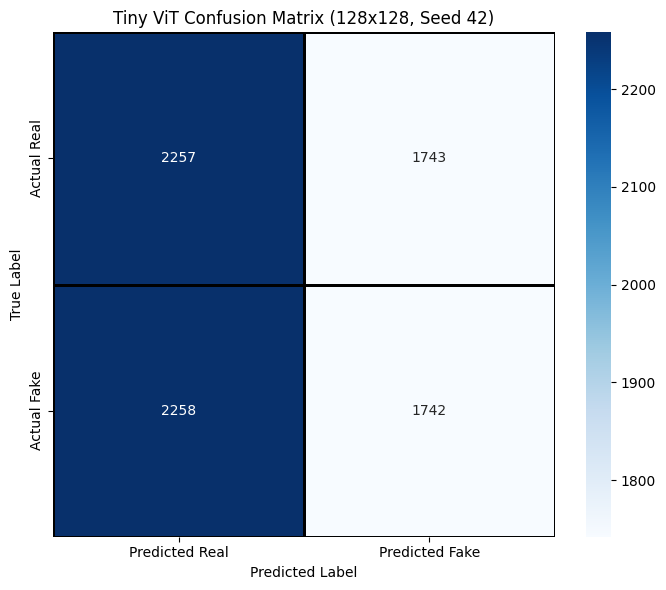

Saved confusion matrix: /content/drive/MyDrive/Thesis_Final_Models/tiny_vit_cm_128_seed42_lr1e5.png

TRAINING TINY ViT | IMAGE SIZE: 224x224 | SEED: 42


TinyViT 224px Epoch [1/15]: 100%|██████████| 250/250 [01:05<00:00,  3.83it/s, acc=49.77%, avg_loss=0.716, batch_loss=0.744]


Epoch [1/15] Average Loss: 0.7159 | Train Accuracy: 49.77%


TinyViT 224px Epoch [2/15]: 100%|██████████| 250/250 [01:06<00:00,  3.74it/s, acc=50.26%, avg_loss=0.703, batch_loss=0.671]


Epoch [2/15] Average Loss: 0.7030 | Train Accuracy: 50.26%


...

Epoch [14/15] Average Loss: 0.6917 | Train Accuracy: 52.65%


TinyViT 224px Epoch [15/15]: 100%|██████████| 250/250 [01:00<00:00,  4.15it/s, acc=52.49%, avg_loss=0.695, batch_loss=0.694]


Epoch [15/15] Average Loss: 0.6926 | Train Accuracy: 52.49%

Saved Tiny ViT model: /content/drive/MyDrive/Thesis_Final_Models/tiny_vit_224_patch16_seed42_lr1e5.pth


Testing TinyViT 224px: 100%|██████████| 125/125 [00:28<00:00,  4.45it/s]



========== FINAL TINY ViT TEST RESULTS ==========
Image Size: 224x224
Patch Size: 16x16
Seed: 42
Learning Rate: 1e-05

True Positive  (Fake detected as Fake): 2263
True Negative  (Real detected as Real): 1726
False Positive (Real detected as Fake): 2274
False Negative (Fake detected as Real): 1737

Accuracy : 0.498625
Precision: 0.4987877452060833
Recall   : 0.56575
F1-score : 0.5301628206629964

========== SPOOF DETECTION RESULT ==========
Total Fake Samples: 4000
Detected Fake Samples: 2263
Fake Detected as Real: 1737

Success Rate: 56.57%
Attack Pass Rate: 43.43%

Prediction Distribution:
Predicted Real: 3463
Predicted Fake: 4537


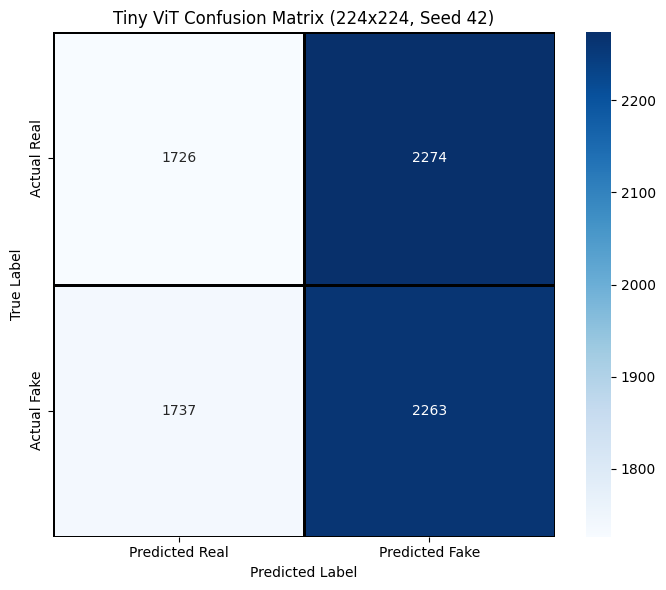

Saved confusion matrix: /content/drive/MyDrive/Thesis_Final_Models/tiny_vit_cm_224_seed42_lr1e5.png

TRAINING TINY ViT | IMAGE SIZE: 256x256 | SEED: 42


TinyViT 256px Epoch [1/15]: 100%|██████████| 250/250 [00:59<00:00,  4.21it/s, acc=49.77%, avg_loss=0.729, batch_loss=0.778]


Epoch [1/15] Average Loss: 0.7287 | Train Accuracy: 49.77%


TinyViT 256px Epoch [2/15]: 100%|██████████| 250/250 [00:59<00:00,  4.17it/s, acc=49.79%, avg_loss=0.713, batch_loss=0.713]


Epoch [2/15] Average Loss: 0.7126 | Train Accuracy: 49.79%


...

Epoch [14/15] Average Loss: 0.6929 | Train Accuracy: 52.43%


TinyViT 256px Epoch [15/15]: 100%|██████████| 250/250 [01:01<00:00,  4.08it/s, acc=52.70%, avg_loss=0.691, batch_loss=0.694]


Epoch [15/15] Average Loss: 0.6914 | Train Accuracy: 52.70%

Saved Tiny ViT model: /content/drive/MyDrive/Thesis_Final_Models/tiny_vit_256_patch16_seed42_lr1e5.pth


Testing TinyViT 256px: 100%|██████████| 125/125 [00:30<00:00,  4.17it/s]



========== FINAL TINY ViT TEST RESULTS ==========
Image Size: 256x256
Patch Size: 16x16
Seed: 42
Learning Rate: 1e-05

True Positive  (Fake detected as Fake): 1704
True Negative  (Real detected as Real): 2300
False Positive (Real detected as Fake): 1700
False Negative (Fake detected as Real): 2296

Accuracy : 0.5005
Precision: 0.500587544065805
Recall   : 0.426
F1-score : 0.46029173419773095

========== SPOOF DETECTION RESULT ==========
Total Fake Samples: 4000
Detected Fake Samples: 1704
Fake Detected as Real: 2296

Success Rate: 42.60%
Attack Pass Rate: 57.40%

Prediction Distribution:
Predicted Real: 4596
Predicted Fake: 3404


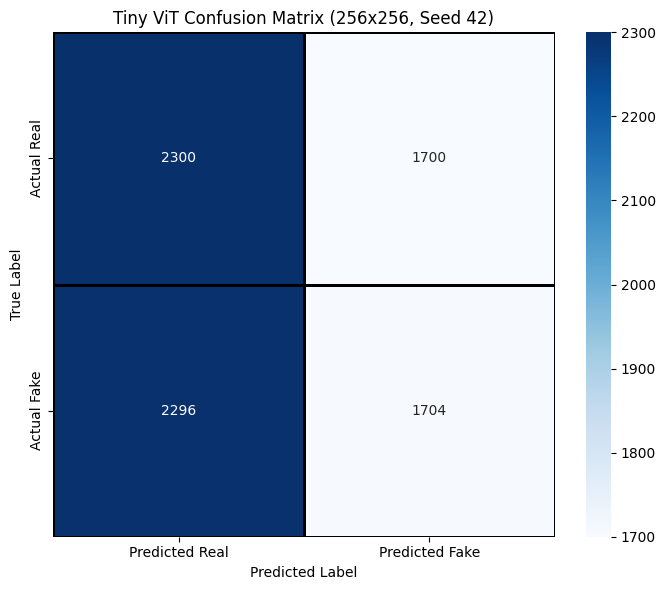

Saved confusion matrix: /content/drive/MyDrive/Thesis_Final_Models/tiny_vit_cm_256_seed42_lr1e5.png


========== TINY ViT SUMMARY: ALL IMAGE SIZES ==========

Image Size: 128
Patch Size: 16
Seed: 42
TP: 1742 | TN: 2257 | FP: 1743 | FN: 2258
Accuracy: 0.499875
Precision: 0.4998565279770445
Recall: 0.4355
F1: 0.4654642618570474
Success Rate: 43.55%
Attack Pass Rate: 56.45%

Image Size: 224
Patch Size: 16
Seed: 42
TP: 2263 | TN: 1726 | FP: 2274 | FN: 1737
Accuracy: 0.498625
Precision: 0.4987877452060833
Recall: 0.56575
F1: 0.5301628206629964
Success Rate: 56.57%
Attack Pass Rate: 43.43%

Image Size: 256
Patch Size: 16
Seed: 42
TP: 1704 | TN: 2300 | FP: 1700 | FN: 2296
Accuracy: 0.5005
Precision: 0.500587544065805
Recall: 0.426
F1: 0.46029173419773095
Success Rate: 42.60%
Attack Pass Rate: 57.40%

Saved Tiny ViT results CSV: /content/drive/MyDrive/Thesis_Final_Models/tiny_vit_results_seed42_lr1e5.csv


In [ ]:


SAVE_DIR = "/content/drive/MyDrive/Thesis_Final_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Saving all files to:", SAVE_DIR)

# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# FIXED SEED
# =========================================================
seed = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed)

# =========================================================
# TRANSFORMER BLOCK
# =========================================================
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, dropout):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)

        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):

        attn_input = self.norm1(x)

        attn_output, _ = self.attn(
            attn_input,
            attn_input,
            attn_input
        )

        x = x + attn_output

        mlp_input = self.norm2(x)

        x = x + self.mlp(mlp_input)

        return x


# =========================================================
# TINY ViT MODEL
# =========================================================
class TinyViT(nn.Module):
    def __init__(
        self,
        image_size=224,
        patch_size=16,
        num_classes=2,
        dim=128,
        depth=4,
        heads=4,
        mlp_dim=256,
        dropout=0.2
    ):
        super().__init__()

        self.image_size = image_size
        self.patch_size = patch_size

        num_patches = (image_size // patch_size) ** 2

        self.patch_embed = nn.Conv2d(
            in_channels=3,
            out_channels=dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        self.pos_embedding = nn.Parameter(
            torch.randn(1, num_patches + 1, dim)
        )

        self.dropout = nn.Dropout(dropout)

        self.transformer = nn.Sequential(
            *[
                TransformerBlock(
                    dim=dim,
                    heads=heads,
                    mlp_dim=mlp_dim,
                    dropout=dropout
                )
                for _ in range(depth)
            ]
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, x):

        B = x.size(0)

        x = self.patch_embed(x)

        x = x.flatten(2).transpose(1, 2)

        cls_tokens = self.cls_token.expand(B, -1, -1)

        x = torch.cat([cls_tokens, x], dim=1)

        x = x + self.pos_embedding

        x = self.dropout(x)

        x = self.transformer(x)

        cls_output = x[:, 0]

        output = self.classifier(cls_output)

        return output


# =========================================================
# TRAIN TINY ViT FOR MULTIPLE IMAGE SIZES
# =========================================================
image_sizes = [128, 224, 256]

vit_patch_size = 16
batch_size = 64
epochs = 15
learning_rate = 0.00001

all_results = []

for img_size in image_sizes:

    set_seed(seed)

    print("\n" + "=" * 70)
    print(f"TRAINING TINY ViT | IMAGE SIZE: {img_size}x{img_size} | SEED: {seed}")
    print("=" * 70)

    # =====================================================
    # TRAIN TRANSFORM
    # =====================================================
    train_transform = transforms.Compose([

        transforms.Resize((img_size, img_size)),

        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomRotation(5),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # =====================================================
    # TEST TRANSFORM
    # =====================================================
    test_transform = transforms.Compose([

        transforms.Resize((img_size, img_size)),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    train_dataset = SpoofDataset(train_data, transform=train_transform)
    test_dataset = SpoofDataset(test_data, transform=test_transform)

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        generator=g
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    # =====================================================
    # MODEL
    # =====================================================
    model = TinyViT(
        image_size=img_size,
        patch_size=vit_patch_size,
        num_classes=2,
        dim=128,
        depth=4,
        heads=4,
        mlp_dim=256,
        dropout=0.3 if img_size == 256 else 0.2
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    # =====================================================
    # TRAINING
    # =====================================================
    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(
            train_loader,
            desc=f"TinyViT {img_size}px Epoch [{epoch+1}/{epochs}]",
            leave=True
        )

        for images, labels in loop:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            train_acc = 100 * correct / total

            loop.set_postfix(
                batch_loss=loss.item(),
                avg_loss=running_loss / (loop.n + 1),
                acc=f"{train_acc:.2f}%"
            )

        avg_loss = running_loss / len(train_loader)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Average Loss: {avg_loss:.4f} | "
            f"Train Accuracy: {train_acc:.2f}%"
        )

    # =====================================================
    # SAVE MODEL
    # =====================================================
    model_path = f"{SAVE_DIR}/tiny_vit_{img_size}_patch16_seed{seed}_lr1e5.pth"

    torch.save(model.state_dict(), model_path)

    print(f"\nSaved Tiny ViT model: {model_path}")

    # =====================================================
    # TESTING
    # =====================================================
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        loop = tqdm(
            test_loader,
            desc=f"Testing TinyViT {img_size}px",
            leave=True
        )

        for images, labels in loop:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # =====================================================
    # METRICS
    # =====================================================
    cm = confusion_matrix(all_labels, all_preds)

    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    total_fake = TP + FN
    detected_fake = TP
    fake_detected_as_real = FN

    success_rate = (detected_fake / total_fake) * 100
    attack_pass_rate = (fake_detected_as_real / total_fake) * 100

    print("\n========== FINAL TINY ViT TEST RESULTS ==========")
    print(f"Image Size: {img_size}x{img_size}")
    print(f"Patch Size: {vit_patch_size}x{vit_patch_size}")
    print(f"Seed: {seed}")
    print(f"Learning Rate: {learning_rate}")

    print("\nTrue Positive  (Fake detected as Fake):", TP)
    print("True Negative  (Real detected as Real):", TN)
    print("False Positive (Real detected as Fake):", FP)
    print("False Negative (Fake detected as Real):", FN)

    print("\nAccuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)

    print("\n========== SPOOF DETECTION RESULT ==========")
    print("Total Fake Samples:", total_fake)
    print("Detected Fake Samples:", detected_fake)
    print("Fake Detected as Real:", fake_detected_as_real)

    print(f"\nSuccess Rate: {success_rate:.2f}%")
    print(f"Attack Pass Rate: {attack_pass_rate:.2f}%")

    print("\nPrediction Distribution:")
    print("Predicted Real:", sum(1 for p in all_preds if p == 0))
    print("Predicted Fake:", sum(1 for p in all_preds if p == 1))

    all_results.append({
        "Model": "Tiny ViT",
        "Seed": seed,
        "Learning Rate": learning_rate,
        "Image Size": img_size,
        "Patch Size": vit_patch_size,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Success Rate": success_rate,
        "Attack Pass Rate": attack_pass_rate
    })

    # =====================================================
    # CONFUSION MATRIX SAVE + SHOW
    # =====================================================
    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=1,
        linecolor="black",
        xticklabels=["Predicted Real", "Predicted Fake"],
        yticklabels=["Actual Real", "Actual Fake"],
        cbar=True
    )

    plt.title(
        f"Tiny ViT Confusion Matrix ({img_size}x{img_size}, Seed {seed})"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()

    cm_path = f"{SAVE_DIR}/tiny_vit_cm_{img_size}_seed{seed}_lr1e5.png"
    plt.savefig(cm_path, dpi=300)

    plt.show()

    print(f"Saved confusion matrix: {cm_path}")


# =========================================================
# FINAL SUMMARY
# =========================================================
print("\n\n========== TINY ViT SUMMARY: ALL IMAGE SIZES ==========")

for r in all_results:

    print("\nImage Size:", r["Image Size"])
    print("Patch Size:", r["Patch Size"])
    print("Seed:", r["Seed"])

    print(
        "TP:", r["TP"],
        "| TN:", r["TN"],
        "| FP:", r["FP"],
        "| FN:", r["FN"]
    )

    print("Accuracy:", r["Accuracy"])
    print("Precision:", r["Precision"])
    print("Recall:", r["Recall"])
    print("F1:", r["F1"])

    print(f"Success Rate: {r['Success Rate']:.2f}%")
    print(f"Attack Pass Rate: {r['Attack Pass Rate']:.2f}%")


# =========================================================
# SAVE RESULTS CSV
# =========================================================
df_results = pd.DataFrame(all_results)

results_path = f"{SAVE_DIR}/tiny_vit_results_seed{seed}_lr1e5.csv"

df_results.to_csv(results_path, index=False)

print("\nSaved Tiny ViT results CSV:", results_path)

## DCT-ViT

Saving all files to: /content/drive/MyDrive/Thesis_Final_Models
Using device: cuda

TRAINING FIRST DCT-ViT | IMAGE SIZE: 128x128


First DCT-ViT 128px Epoch [1/15]: 100%|██████████| 250/250 [00:47<00:00,  5.30it/s, acc=50.34%, avg_loss=0.7, batch_loss=0.712]


Epoch [1/15] Average Loss: 0.7000 | Train Accuracy: 50.34%


First DCT-ViT 128px Epoch [2/15]: 100%|██████████| 250/250 [00:47<00:00,  5.21it/s, acc=51.05%, avg_loss=0.697, batch_loss=0.703]


Epoch [2/15] Average Loss: 0.6969 | Train Accuracy: 51.05%


...

Epoch [14/15] Average Loss: 0.6470 | Train Accuracy: 62.56%


First DCT-ViT 128px Epoch [15/15]: 100%|██████████| 250/250 [00:46<00:00,  5.40it/s, acc=63.02%, avg_loss=0.643, batch_loss=0.621]


Epoch [15/15] Average Loss: 0.6403 | Train Accuracy: 63.02%

Saved model: /content/drive/MyDrive/Thesis_Final_Models/first_dct_vit_128_patch16_seed42.pth


Testing First DCT-ViT 128px: 100%|██████████| 125/125 [00:22<00:00,  5.50it/s]



========== FINAL FIRST DCT-ViT TEST RESULTS ==========
Image Size: 128x128
Patch Size: 16x16
Seed: 42

True Positive  (Fake detected as Fake): 2003
True Negative  (Real detected as Real): 1655
False Positive (Real detected as Fake): 2345
False Negative (Fake detected as Real): 1997

Accuracy : 0.45725
Precision: 0.4606715731370745
Recall   : 0.50075
F1-score : 0.4798754192620987

========== SPOOF DETECTION RESULT ==========
Total Fake Samples: 4000
Detected Fake Samples: 2003
Fake Detected as Real: 1997

Success Rate: 50.08%
Attack Pass Rate: 49.93%

Prediction Distribution:
Predicted Real: 3652
Predicted Fake: 4348


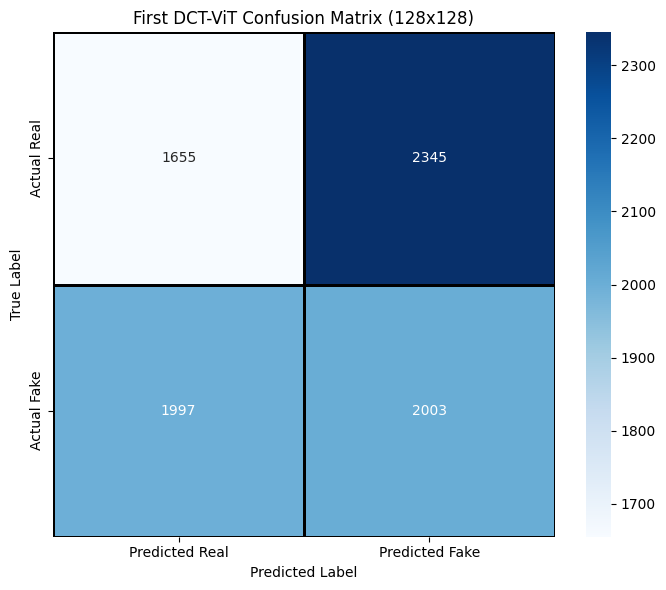

Saved confusion matrix: /content/drive/MyDrive/Thesis_Final_Models/first_dct_vit_cm_128_seed42.png

TRAINING FIRST DCT-ViT | IMAGE SIZE: 224x224


First DCT-ViT 224px Epoch [1/15]: 100%|██████████| 250/250 [00:56<00:00,  4.43it/s, acc=50.71%, avg_loss=0.697, batch_loss=0.689]


Epoch [1/15] Average Loss: 0.6968 | Train Accuracy: 50.71%


First DCT-ViT 224px Epoch [2/15]: 100%|██████████| 250/250 [00:58<00:00,  4.28it/s, acc=51.54%, avg_loss=0.695, batch_loss=0.712]


Epoch [2/15] Average Loss: 0.6951 | Train Accuracy: 51.54%


...

Epoch [14/15] Average Loss: 0.6578 | Train Accuracy: 60.82%


First DCT-ViT 224px Epoch [15/15]: 100%|██████████| 250/250 [00:56<00:00,  4.41it/s, acc=61.02%, avg_loss=0.659, batch_loss=0.67]


Epoch [15/15] Average Loss: 0.6567 | Train Accuracy: 61.02%

Saved model: /content/drive/MyDrive/Thesis_Final_Models/first_dct_vit_224_patch16_seed42.pth


Testing First DCT-ViT 224px: 100%|██████████| 125/125 [00:27<00:00,  4.57it/s]



========== FINAL FIRST DCT-ViT TEST RESULTS ==========
Image Size: 224x224
Patch Size: 16x16
Seed: 42

True Positive  (Fake detected as Fake): 2490
True Negative  (Real detected as Real): 1186
False Positive (Real detected as Fake): 2814
False Negative (Fake detected as Real): 1510

Accuracy : 0.4595
Precision: 0.46945701357466063
Recall   : 0.6225
F1-score : 0.5352536543422184

========== SPOOF DETECTION RESULT ==========
Total Fake Samples: 4000
Detected Fake Samples: 2490
Fake Detected as Real: 1510

Success Rate: 62.25%
Attack Pass Rate: 37.75%

Prediction Distribution:
Predicted Real: 2696
Predicted Fake: 5304


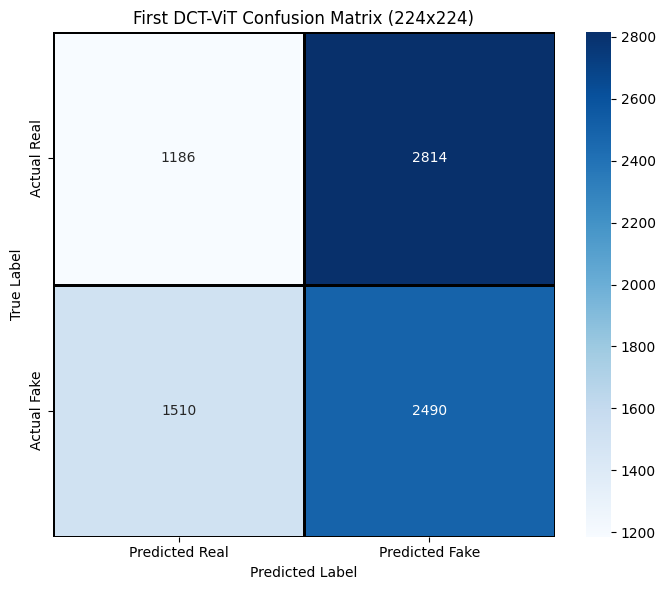

Saved confusion matrix: /content/drive/MyDrive/Thesis_Final_Models/first_dct_vit_cm_224_seed42.png

TRAINING FIRST DCT-ViT | IMAGE SIZE: 256x256


First DCT-ViT 256px Epoch [1/15]: 100%|██████████| 250/250 [00:55<00:00,  4.49it/s, acc=50.23%, avg_loss=0.698, batch_loss=0.68]


Epoch [1/15] Average Loss: 0.6981 | Train Accuracy: 50.23%


First DCT-ViT 256px Epoch [2/15]: 100%|██████████| 250/250 [00:59<00:00,  4.21it/s, acc=51.10%, avg_loss=0.699, batch_loss=0.699]


Epoch [2/15] Average Loss: 0.6959 | Train Accuracy: 51.10%


...

Epoch [14/15] Average Loss: 0.3524 | Train Accuracy: 85.19%


First DCT-ViT 256px Epoch [15/15]: 100%|██████████| 250/250 [00:57<00:00,  4.35it/s, acc=93.49%, avg_loss=0.173, batch_loss=0.18]


Epoch [15/15] Average Loss: 0.1731 | Train Accuracy: 93.49%

Saved model: /content/drive/MyDrive/Thesis_Final_Models/first_dct_vit_256_patch16_seed42.pth


Testing First DCT-ViT 256px: 100%|██████████| 125/125 [00:28<00:00,  4.40it/s]



========== FINAL FIRST DCT-ViT TEST RESULTS ==========
Image Size: 256x256
Patch Size: 16x16
Seed: 42

True Positive  (Fake detected as Fake): 57
True Negative  (Real detected as Real): 3991
False Positive (Real detected as Fake): 9
False Negative (Fake detected as Real): 3943

Accuracy : 0.506
Precision: 0.8636363636363636
Recall   : 0.01425
F1-score : 0.028037383177570093

========== SPOOF DETECTION RESULT ==========
Total Fake Samples: 4000
Detected Fake Samples: 57
Fake Detected as Real: 3943

Success Rate: 1.43%
Attack Pass Rate: 98.58%

Prediction Distribution:
Predicted Real: 7934
Predicted Fake: 66


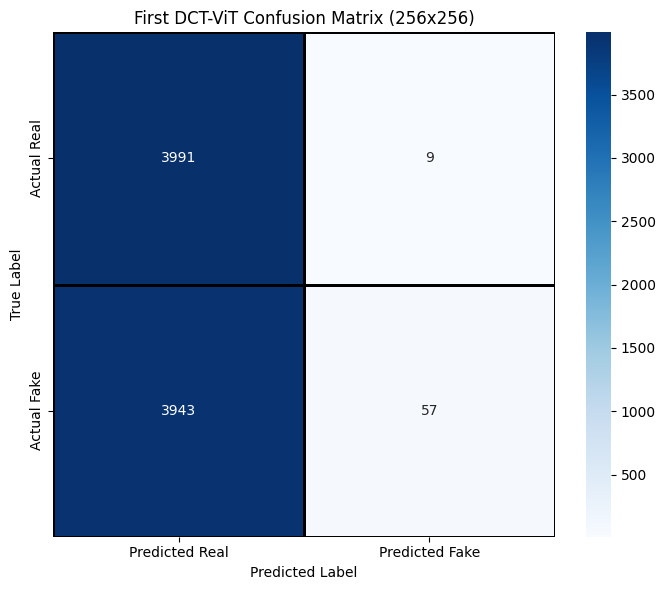

Saved confusion matrix: /content/drive/MyDrive/Thesis_Final_Models/first_dct_vit_cm_256_seed42.png


========== FIRST DCT-ViT SUMMARY ==========

Image Size: 128
Patch Size: 16
Seed: 42
TP: 2003 | TN: 1655 | FP: 2345 | FN: 1997
Accuracy: 0.45725
Precision: 0.4606715731370745
Recall: 0.50075
F1: 0.4798754192620987
Success Rate: 50.08%
Attack Pass Rate: 49.93%

Image Size: 224
Patch Size: 16
Seed: 42
TP: 2490 | TN: 1186 | FP: 2814 | FN: 1510
Accuracy: 0.4595
Precision: 0.46945701357466063
Recall: 0.6225
F1: 0.5352536543422184
Success Rate: 62.25%
Attack Pass Rate: 37.75%

Image Size: 256
Patch Size: 16
Seed: 42
TP: 57 | TN: 3991 | FP: 9 | FN: 3943
Accuracy: 0.506
Precision: 0.8636363636363636
Recall: 0.01425
F1: 0.028037383177570093
Success Rate: 1.43%
Attack Pass Rate: 98.58%

Saved results CSV: /content/drive/MyDrive/Thesis_Final_Models/first_dct_vit_results_seed42.csv


In [ ]:
# =========================================================
# FIRST DCT-ViT TRAINING + TESTING
# Full Image DCT Map + Tiny ViT Backbone
# =========================================================


# =========================================================
# SAVE DIRECTORY
# =========================================================
SAVE_DIR = "/content/drive/MyDrive/Thesis_Final_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Saving all files to:", SAVE_DIR)

# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# FIXED SEED
# =========================================================
seed = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed)

# =========================================================
# DCT MATRIX
# =========================================================
def create_dct_matrix(N):
    dct = torch.zeros((N, N))

    for k in range(N):
        for n in range(N):
            alpha = math.sqrt(1 / N) if k == 0 else math.sqrt(2 / N)
            dct[k, n] = alpha * math.cos(
                math.pi * (2 * n + 1) * k / (2 * N)
            )

    return dct


# =========================================================
# DCT FREQUENCY MODULE
# =========================================================
class DCTFrequencyModule(nn.Module):
    def __init__(self, image_size):
        super().__init__()

        dct_matrix = create_dct_matrix(image_size)
        self.register_buffer("dct_matrix", dct_matrix)

    def forward(self, x):

        gray = (
            0.299 * x[:, 0:1, :, :] +
            0.587 * x[:, 1:2, :, :] +
            0.114 * x[:, 2:3, :, :]
        )

        gray = gray.squeeze(1)

        C = self.dct_matrix

        dct = torch.matmul(C, gray)
        dct = torch.matmul(dct, C.t())

        dct = torch.log1p(torch.abs(dct))

        dct_min = dct.amin(dim=(1, 2), keepdim=True)
        dct_max = dct.amax(dim=(1, 2), keepdim=True)

        dct = (dct - dct_min) / (dct_max - dct_min + 1e-8)

        dct = dct.unsqueeze(1)

        return dct


# =========================================================
# TRANSFORMER BLOCK
# =========================================================
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, dropout):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)

        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):

        attn_input = self.norm1(x)

        attn_output, _ = self.attn(
            attn_input,
            attn_input,
            attn_input
        )

        x = x + attn_output

        mlp_input = self.norm2(x)

        x = x + self.mlp(mlp_input)

        return x


# =========================================================
# FIRST DCT-TINY ViT MODEL
# =========================================================
class DCTTinyViT(nn.Module):
    def __init__(
        self,
        image_size=224,
        patch_size=16,
        num_classes=2,
        dim=128,
        depth=4,
        heads=4,
        mlp_dim=256,
        dropout=0.25
    ):
        super().__init__()

        self.image_size = image_size
        self.patch_size = patch_size

        num_patches = (image_size // patch_size) ** 2

        self.dct_module = DCTFrequencyModule(image_size)

        self.spatial_patch_embed = nn.Conv2d(
            in_channels=3,
            out_channels=dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        self.freq_patch_embed = nn.Conv2d(
            in_channels=1,
            out_channels=dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        self.fusion = nn.Linear(dim * 2, dim)

        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        self.pos_embedding = nn.Parameter(
            torch.randn(1, num_patches + 1, dim)
        )

        self.dropout = nn.Dropout(dropout)

        self.transformer = nn.Sequential(
            *[
                TransformerBlock(
                    dim=dim,
                    heads=heads,
                    mlp_dim=mlp_dim,
                    dropout=dropout
                )
                for _ in range(depth)
            ]
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

    def forward(self, x):

        B = x.size(0)

        spatial_tokens = self.spatial_patch_embed(x)
        spatial_tokens = spatial_tokens.flatten(2).transpose(1, 2)

        dct_map = self.dct_module(x)

        freq_tokens = self.freq_patch_embed(dct_map)
        freq_tokens = freq_tokens.flatten(2).transpose(1, 2)

        tokens = torch.cat(
            [spatial_tokens, freq_tokens],
            dim=-1
        )

        tokens = self.fusion(tokens)

        cls_tokens = self.cls_token.expand(B, -1, -1)

        tokens = torch.cat(
            [cls_tokens, tokens],
            dim=1
        )

        tokens = tokens + self.pos_embedding

        tokens = self.dropout(tokens)

        tokens = self.transformer(tokens)

        cls_output = tokens[:, 0]

        output = self.classifier(cls_output)

        return output


# =========================================================
# TRAIN CONFIG
# =========================================================
image_sizes = [128, 224, 256]

vit_patch_size = 16
batch_size = 64
epochs = 15
learning_rate = 0.00001

all_results = []

# =========================================================
# TRAIN + TEST LOOP
# =========================================================
for img_size in image_sizes:

    set_seed(seed)

    print("\n" + "=" * 70)
    print(f"TRAINING FIRST DCT-ViT | IMAGE SIZE: {img_size}x{img_size}")
    print("=" * 70)

    # =====================================================
    # TRAIN TRANSFORM
    # SAME AS TINY ViT
    # =====================================================
    train_transform = transforms.Compose([

        transforms.Resize((img_size, img_size)),

        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomRotation(5),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # =====================================================
    # TEST TRANSFORM
    # =====================================================
    test_transform = transforms.Compose([

        transforms.Resize((img_size, img_size)),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    train_dataset = SpoofDataset(
        train_data,
        transform=train_transform
    )

    test_dataset = SpoofDataset(
        test_data,
        transform=test_transform
    )

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        generator=g
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    # =====================================================
    # MODEL
    # =====================================================
    model = DCTTinyViT(
        image_size=img_size,
        patch_size=vit_patch_size,
        num_classes=2,
        dim=128,
        depth=4,
        heads=4,
        mlp_dim=256,
        dropout=0.05
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    # =====================================================
    # TRAINING
    # =====================================================
    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(
            train_loader,
            desc=f"First DCT-ViT {img_size}px Epoch [{epoch+1}/{epochs}]",
            leave=True
        )

        for images, labels in loop:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            train_acc = 100 * correct / total

            loop.set_postfix(
                batch_loss=loss.item(),
                avg_loss=running_loss / (loop.n + 1),
                acc=f"{train_acc:.2f}%"
            )

        avg_loss = running_loss / len(train_loader)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Average Loss: {avg_loss:.4f} | "
            f"Train Accuracy: {train_acc:.2f}%"
        )

    # =====================================================
    # SAVE MODEL
    # =====================================================
    model_path = (
        f"{SAVE_DIR}/first_dct_vit_{img_size}_patch16_seed{seed}.pth"
    )

    torch.save(
        model.state_dict(),
        model_path
    )

    print(f"\nSaved model: {model_path}")

    # =====================================================
    # TESTING
    # =====================================================
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        loop = tqdm(
            test_loader,
            desc=f"Testing First DCT-ViT {img_size}px",
            leave=True
        )

        for images, labels in loop:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # =====================================================
    # METRICS
    # =====================================================
    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    total_fake = TP + FN
    detected_fake = TP
    fake_detected_as_real = FN

    success_rate = (
        detected_fake / total_fake
    ) * 100

    attack_pass_rate = (
        fake_detected_as_real / total_fake
    ) * 100

    print("\n========== FINAL FIRST DCT-ViT TEST RESULTS ==========")

    print(f"Image Size: {img_size}x{img_size}")
    print(f"Patch Size: {vit_patch_size}x{vit_patch_size}")
    print(f"Seed: {seed}")

    print("\nTrue Positive  (Fake detected as Fake):", TP)
    print("True Negative  (Real detected as Real):", TN)
    print("False Positive (Real detected as Fake):", FP)
    print("False Negative (Fake detected as Real):", FN)

    print("\nAccuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)

    print("\n========== SPOOF DETECTION RESULT ==========")

    print("Total Fake Samples:", total_fake)
    print("Detected Fake Samples:", detected_fake)
    print("Fake Detected as Real:", fake_detected_as_real)

    print(f"\nSuccess Rate: {success_rate:.2f}%")
    print(f"Attack Pass Rate: {attack_pass_rate:.2f}%")

    print("\nPrediction Distribution:")
    print("Predicted Real:", sum(1 for p in all_preds if p == 0))
    print("Predicted Fake:", sum(1 for p in all_preds if p == 1))

    all_results.append({
        "Model": "First DCT-ViT",
        "Seed": seed,
        "Image Size": img_size,
        "Patch Size": vit_patch_size,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Success Rate": success_rate,
        "Attack Pass Rate": attack_pass_rate
    })

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================
    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=1,
        linecolor="black",
        xticklabels=["Predicted Real", "Predicted Fake"],
        yticklabels=["Actual Real", "Actual Fake"],
        cbar=True
    )

    plt.title(
        f"First DCT-ViT Confusion Matrix ({img_size}x{img_size})"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()

    cm_path = (
        f"{SAVE_DIR}/first_dct_vit_cm_{img_size}_seed{seed}.png"
    )

    plt.savefig(
        cm_path,
        dpi=300
    )

    plt.show()

    print(f"Saved confusion matrix: {cm_path}")


# =========================================================
# FINAL SUMMARY
# =========================================================
print("\n\n========== FIRST DCT-ViT SUMMARY ==========")

for r in all_results:

    print("\nImage Size:", r["Image Size"])
    print("Patch Size:", r["Patch Size"])
    print("Seed:", r["Seed"])

    print(
        "TP:", r["TP"],
        "| TN:", r["TN"],
        "| FP:", r["FP"],
        "| FN:", r["FN"]
    )

    print("Accuracy:", r["Accuracy"])
    print("Precision:", r["Precision"])
    print("Recall:", r["Recall"])
    print("F1:", r["F1"])

    print(f"Success Rate: {r['Success Rate']:.2f}%")
    print(f"Attack Pass Rate: {r['Attack Pass Rate']:.2f}%")


# =========================================================
# SAVE RESULTS CSV
# =========================================================
df_results = pd.DataFrame(all_results)

results_path = (
    f"{SAVE_DIR}/first_dct_vit_results_seed{seed}.csv"
)

df_results.to_csv(
    results_path,
    index=False
)

print("\nSaved results CSV:", results_path)